# **ML Project Phase 2: Data Preprocessing & EDA**
## **Early Detection of Preclampsia**
#### By: Dana Mounayer, Sedra Al Jundi, Judy Al Imam

## **--- Maternal Health Risk Dataset ---**

### **Part 1: Setup & Data Loading**

### **1.1 Import Required Libraries**

In [277]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Utilities
import warnings
warnings.filterwarnings('ignore')

### **1.2 Upload Dataset**

In [278]:
df = pd.read_csv("/content/Maternal Health Risk Dataset.csv")
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


### **1.3 Basic Data Inspection**

In [279]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


(1014, 7)

### **Part 2: Exploratory Data Analysis (EDA)**

### **2.1 Class Distribution**

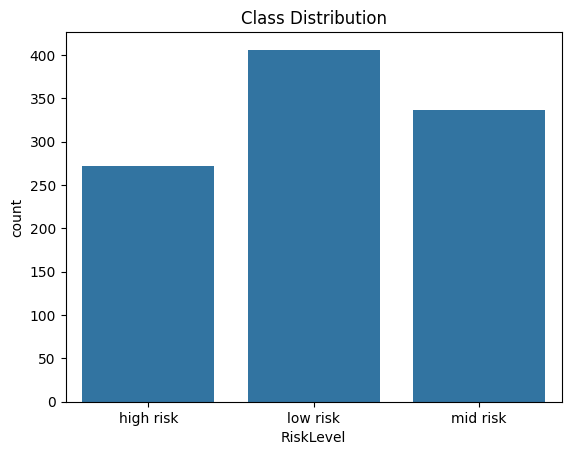

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [280]:
sns.countplot(x='RiskLevel', data=df)
plt.title("Class Distribution")
plt.show()

print(df['RiskLevel'].value_counts())

The class distribution indicates a slight imbalance, where low-risk cases dominate the dataset, and high-risk cases are underrepresented. This imbalance may negatively affect model performance, particularly in detecting high-risk pregnancies.

### **2.2 Missing Values**

In [281]:
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


The dataset is clean with no missing values across all features, eliminating the need for imputation techniques.

### **2.3 Detect Outliers**

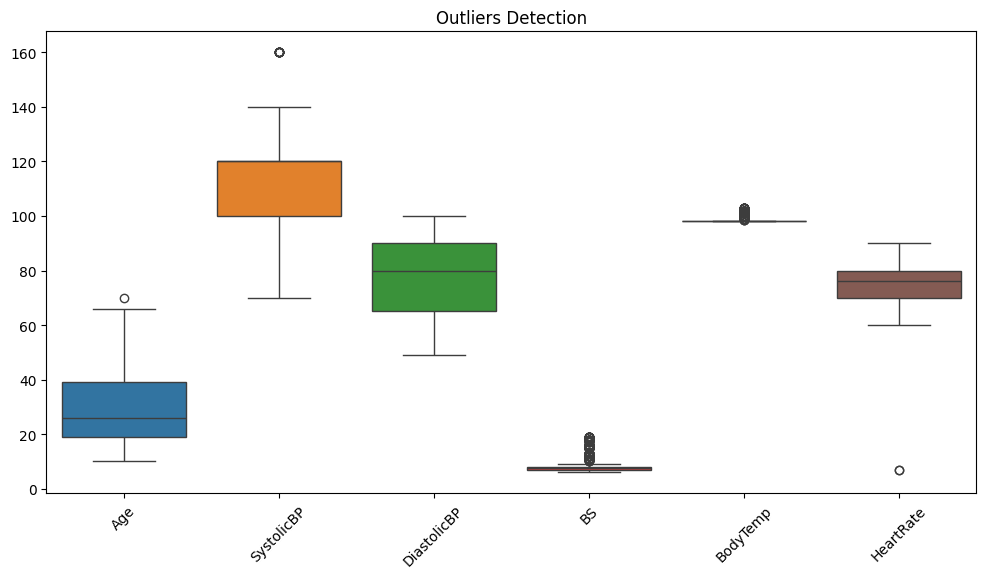

In [282]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Outliers Detection")
plt.show()

Boxplot analysis shows the presence of outliers in multiple features, particularly Blood Sugar and Systolic Blood Pressure.

**In medical datasets, extreme values may represent real critical conditions**

Example: very high blood pressure = dangerous patient

so we will not remove them

### **2.4 Feature Distribution (Histograms)**

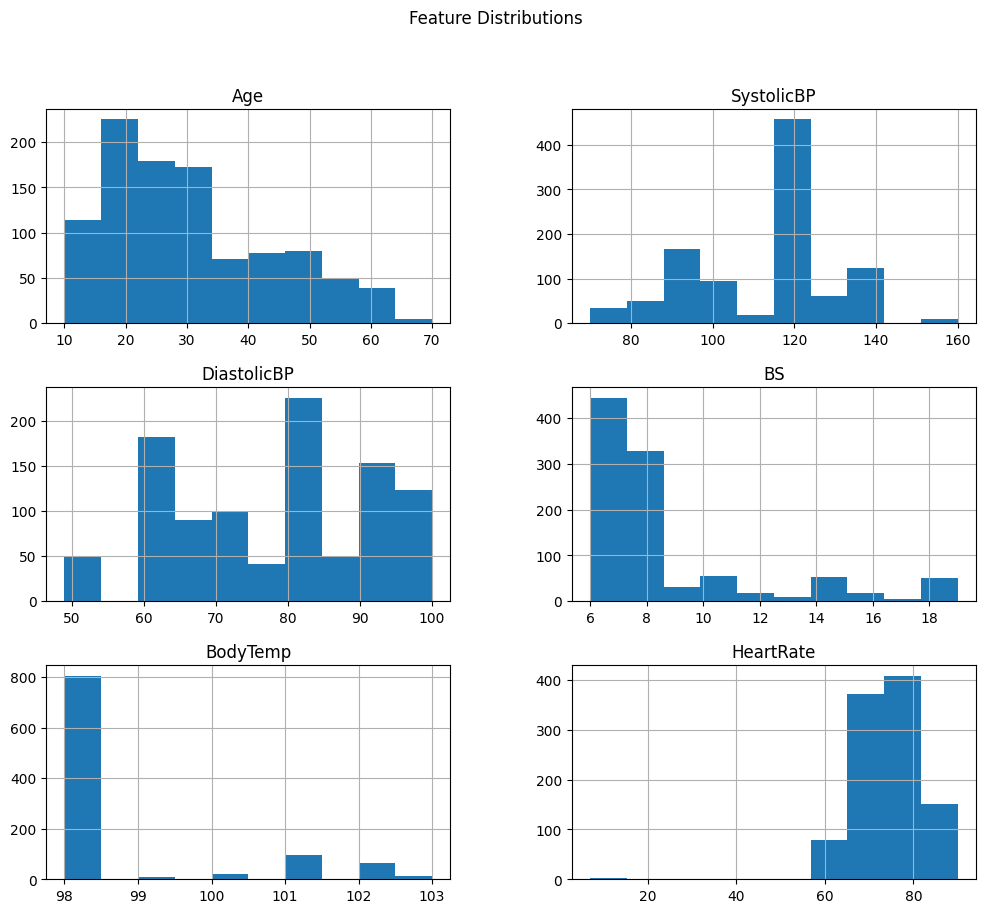

In [283]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

The feature distributions reveal that most variables follow reasonable medical ranges. However, Blood Sugar (BS) is highly skewed with extreme values, and Body Temperature shows very low variance, which may limit its contribution to prediction.

### **2.5 Correlation Heatmap**

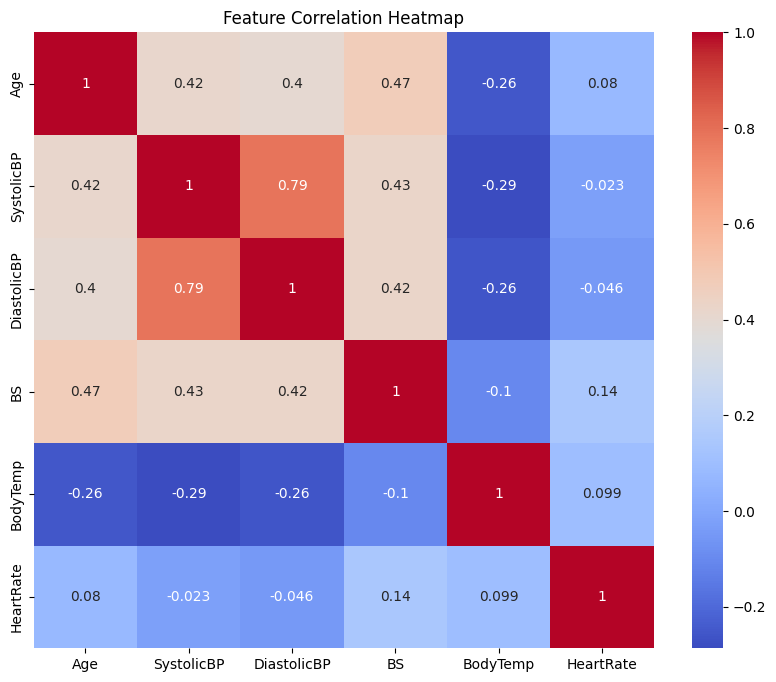

In [284]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('RiskLevel', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Correlation analysis indicates a strong relationship between systolic and diastolic blood pressure, while other features show relatively weak correlations. This suggests that most features contribute independently to the prediction task.

### **Part 3: Preprocessing Pipeline**



### **3.1 Encode Target Variable**

In [285]:
# Convert RiskLevel from categorical to numerical values
# Example: low risk = 0, mid risk = 1, high risk = 2

le = LabelEncoder()
df['RiskLevel'] = le.fit_transform(df['RiskLevel'])

Encoding is necessary since ML models cannot handle categorical labels directly.

### **3.2 Feature & Target Split**

In [286]:
# Separate input features (X) and target variable (y)

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

### **3.3 Train / Validation / Test Split**

In [287]:
from sklearn.model_selection import train_test_split
# Split dataset into:
# 70% training, 15% validation, 15% testing

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

### **3.4 Feature Scaling**

In [288]:
# Standardize features to have mean = 0 and std = 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scaling ensures all features contribute equally and prevents dominance of large-scale features like BP.

### **Part 4: Inject Adversarial Condition**

### **4.1 Handle Imbalance (SMOTE)**

In [289]:
# Apply on training data to handle class imbalance

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

SMOTE was applied to the training data to address class imbalance by generating synthetic samples for minority classes, improving the model’s ability to detect high-risk cases.

### **4.2 Label Noise**

In [290]:
def inject_label_noise(y, noise_level=0.1):
    y_noisy = y.copy()
    n_samples = int(len(y) * noise_level)

    indices = np.random.choice(len(y), n_samples, replace=False)
    unique_classes = np.unique(y)

    for i in indices:
        current = y[i]
        choices = list(unique_classes)
        choices.remove(current)
        y_noisy[i] = np.random.choice(choices)

    return y_noisy

y_train_noisy = inject_label_noise(y_train_balanced, 0.1)

Label noise was introduced by randomly flipping 10% of the training labels to simulate real-world diagnostic errors, allowing evaluation of model robustness under noisy conditions.

**SMOTE and label noise were applied only to the training set to avoid data leakage**

## **--- Factors for Preeclampsia Dataset ---**

### **Part 1: Setup & Data Loading**

### **1.1 Load Factors for Preeclampsia Dataset**

In [291]:
df2 = pd.read_csv("/content/preeclampsia.csv")
df2.head()

,age,gest_age,height,weight,bmi,sysbp,diabp,hb,pcv,tsh,...,pp_13,glycerides,htn,diabetes,fam_htn,sp_art,occupation,diet,activity,sleep
0,28,11,152,97,28.508125,71,133,14.683883,39.232347,2.764080,...,61.197945,257.668101,0,0,1,0,1,0,2,1
1,28,12,157,70,27.606337,87,127,14.510683,38.215125,2.439556,...,95.611529,269.812342,1,0,1,1,2,1,2,2
2,21,11,173,98,25.673333,76,128,12.592319,39.245587,4.147177,...,26.671472,197.074922,1,1,0,1,2,0,1,1
3,30,12,148,65,27.367781,82,122,14.128237,37.276060,2.118313,...,83.365411,244.343060,0,0,0,0,0,0,0,0
4,23,11,157,71,21.585036,76,139,13.089027,40.280974,1.186492,...,117.633252,239.124513,1,1,1,0,1,1,2,2


### **1.2 Basic Data Inspection**

In [292]:
df2.info()
df2.describe()
df2.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         400 non-null    int64  
 1   gest_age    400 non-null    int64  
 2   height      400 non-null    int64  
 3   weight      400 non-null    int64  
 4   bmi         400 non-null    float64
 5   sysbp       400 non-null    int64  
 6   diabp       400 non-null    int64  
 7   hb          400 non-null    float64
 8   pcv         400 non-null    float64
 9   tsh         400 non-null    float64
 10  platelet    400 non-null    int64  
 11  creatinine  400 non-null    float64
 12  plgf:sflt   400 non-null    float64
 13  SEng        400 non-null    float64
 14  cysC        400 non-null    float64
 15  pp_13       400 non-null    float64
 16  glycerides  400 non-null    float64
 17  htn         400 non-null    int64  
 18  diabetes    400 non-null    int64  
 19  fam_htn     400 non-null    i

(400, 25)

The dataset consists of 400 records with 25 features representing demographic, physiological, and biochemical factors associated with preeclampsia.

**All features are numerical, eliminating the need for categorical encoding and simplifying preprocessing.**

### **Part 2: Exploratory Data Analysis (EDA)**

### **2.1 Class Distribution**

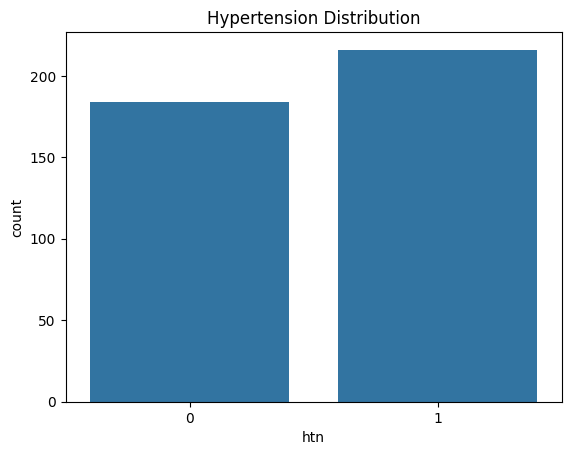

In [293]:
sns.countplot(x='htn', data=df2)
plt.title("Hypertension Distribution")
plt.show()

The class distribution plot shows that the dataset is relatively balanced between the two classes (0 and 1). This balance is important as it reduces the risk of model bias toward one class and allows for more reliable performance evaluation.

### **2.2 Missing Values**

In [294]:
df2.isnull().sum()

,0
age,0
gest_age,0
height,0
weight,0
bmi,0
sysbp,0
diabp,0
hb,0
pcv,0
tsh,0


The dataset is complete with no missing values, ensuring data consistency and eliminating the need for imputation.

### **2.3 Detect Outliers**

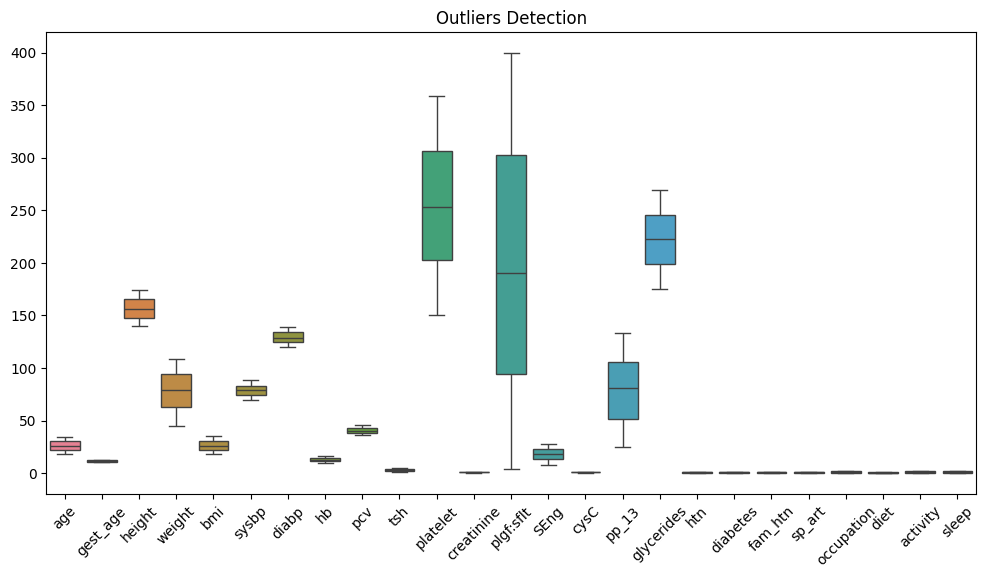

In [295]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df2.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Outliers Detection")
plt.show()

The boxplot illustrates the presence of outliers across multiple numerical features in the dataset. Several variables such as plgf:sflt, platelet, glycerides, and pp_13 exhibit noticeable variability with extreme values beyond the interquartile range. These outliers likely reflect real physiological differences rather than data errors, which is common in medical datasets. On the other hand, binary features such as htn and diabetes show no outliers due to their discrete nature. Overall, the dataset contains moderate to high variability, making feature scaling essential before model training.

### **2.4 Handle Outliers**

In [296]:
def cap_outliers(df, cols):
    df_capped = df.copy()

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_capped[col] = np.clip(df[col], lower, upper)

    return df_capped

continuous_cols = df2.select_dtypes(include=np.number).columns
df2 = cap_outliers(df2, continuous_cols)

Outliers were handled using the IQR capping method, where extreme values were limited within a calculated range instead of being removed. This approach preserves important medical information while reducing the impact of extreme values on model performance.

### **2.5 Feature Distribution (Histograms)**

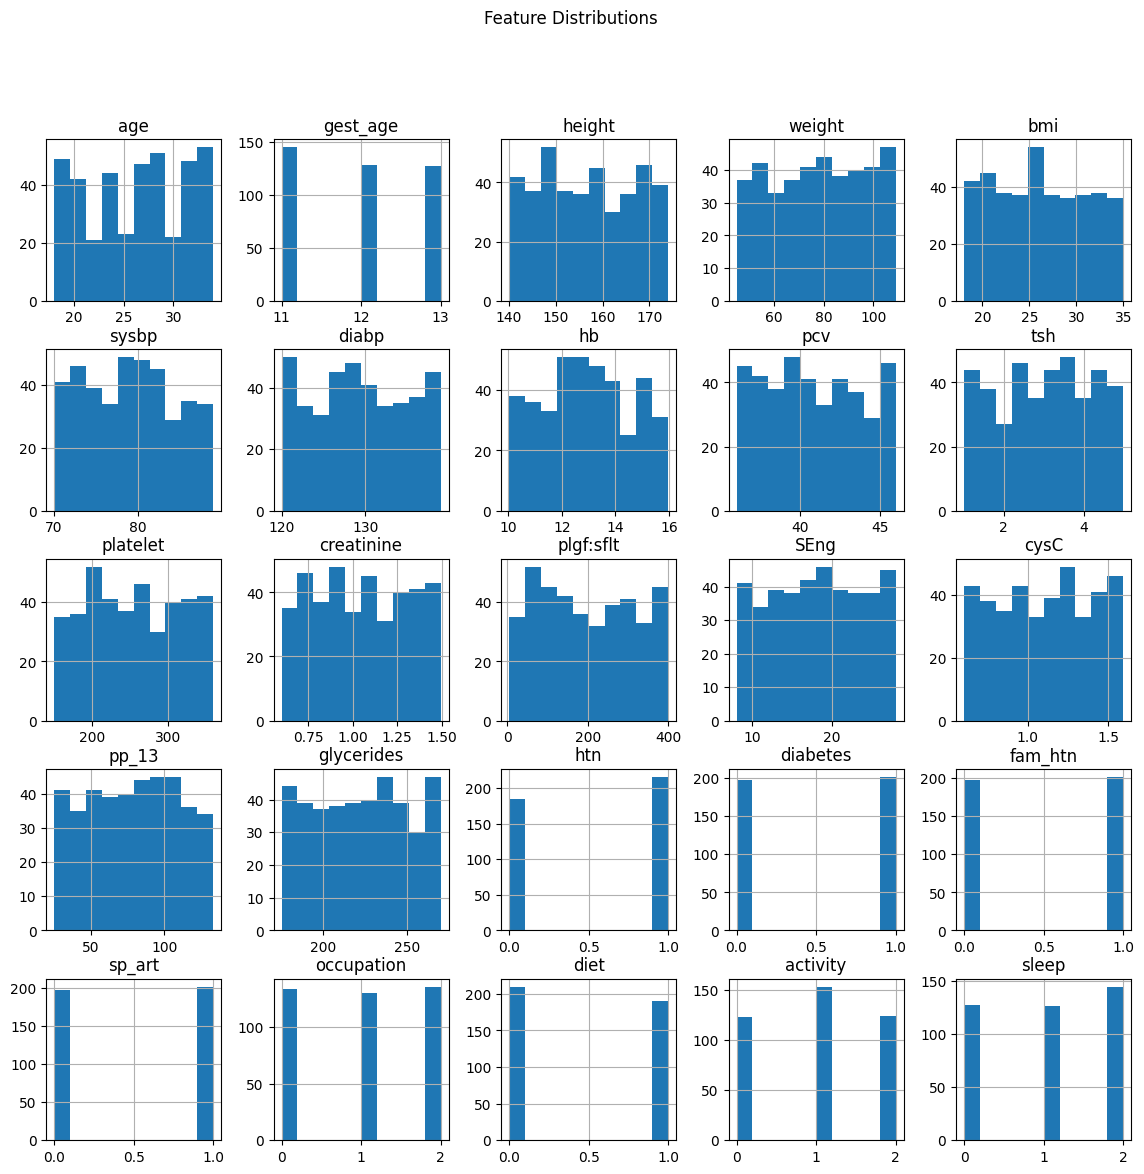

In [297]:
df2.hist(figsize=(14,13))
plt.suptitle("Feature Distributions")
plt.show()

Continuous variables such as age, height, weight, and bmi show relatively balanced distributions, indicating good variability among patients. Some features like plgf:sflt and glycerides appear slightly skewed, suggesting the presence of extreme values. Discrete variables such as gest_age, occupation, diet, and activity have limited unique values, indicating categorical-like behavior. Binary features such as htn and diabetes are fairly balanced, which is beneficial for model training. Overall, the dataset demonstrates a mix of continuous and discrete distributions.

### **2.6 Correlation Heatmap**

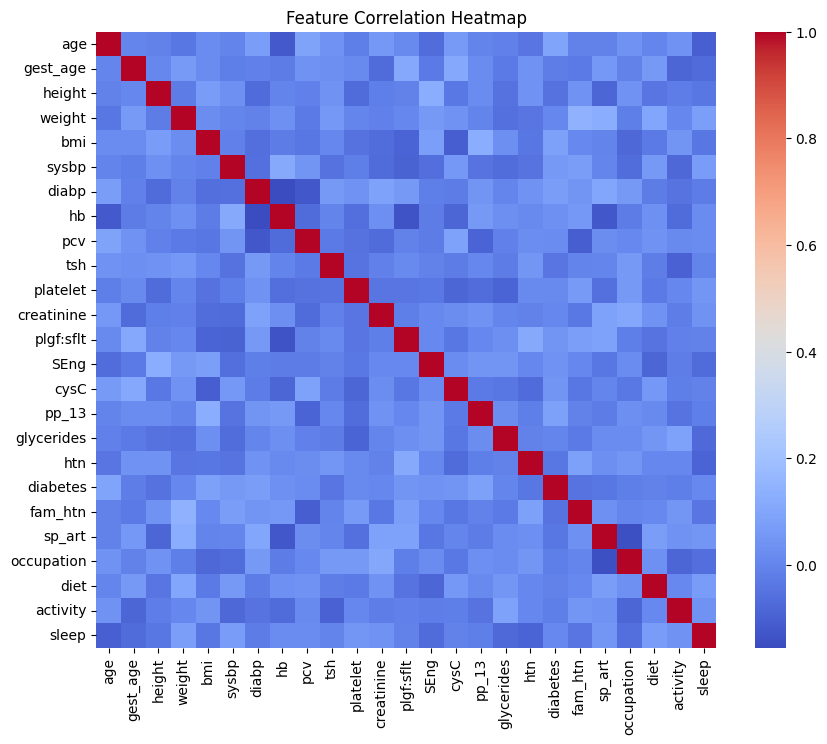

In [298]:
plt.figure(figsize=(10,8))
sns.heatmap(df2.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### **Part 3: Preprocessing Pipeline**

### **3.1 Encoding**
**All features are numerical, eliminating the need for categorical encoding and simplifying preprocessing.**

### **3.2 Define Features & Target**

In [299]:
X = df2.drop("htn", axis=1)   # Features
y = df2["htn"]                # Target variable

### **3.3 Train / Validation / Test Split**

In [300]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (280, 24)
Validation: (60, 24)
Test: (60, 24)


### **3.4 Feature Scaling (Standardization)**

In [301]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

### **3.5 Handle Skewed Features**

In [302]:
skewed_cols = ["plgf:sflt", "glycerides"]

for col in skewed_cols:
    df2[col] = np.log1p(df2[col])

### **Part 4: Inject Adversarial Condition**

### **4.1 Inject Label Noise (15%)**

In [303]:
def add_label_noise(y, noise_ratio=0.15):
    y_noisy = y.copy()
    n_samples = int(len(y) * noise_ratio)

    indices = np.random.choice(len(y), n_samples, replace=False)

    for i in indices:
        y_noisy.iloc[i] = 1 - y_noisy.iloc[i]  # Flip labels

    return y_noisy

y_train_noisy = add_label_noise(y_train, 0.15)

### **4.2 Feature Noise (Concept Drift)**

In [304]:
X_train_drifted = X_train.copy()

X_train_drifted["sysbp"] += np.random.normal(0, 5, size=len(X_train))

## **--- Preeclampsia in Pregnant Women Dataset ---**

### **Part 1: Setup & Data Loading**

### **1.1 Load Dataset**

In [305]:
# Load Excel files
train_df = pd.read_excel("/content/train_dataset.xlsx")
test_df  = pd.read_excel("/content/test_dataset.xlsx")

train_df.head()

,gravida,parity,gestational age (weeks),Age (yrs),BMI [kg/m²],diabetes,History of hypertension (y/n),Systolic BP,Diastolic BP,HB,fetal weight(kgs),Protien Uria,Unnamed: 12,Uterine Artery Doppler Resistance Index (RI),Uterine Artery Doppler Pulsatility Index (PI,amniotic fluid levels(cm),Risk_level
0,4,2,26.0,22,17.2,1,0,130,80,8.5,0.6320,0,NaN,NaN,NaN,10.0,mid
1,3,3,30.0,29,21.2,0,0,110,60,8.3,0.9840,0,NaN,NaN,NaN,9.5,low
2,7,4,26.2,35,31.2,0,0,110,60,10.8,0.0076,0,NaN,NaN,NaN,14.2,mid
3,3,1,22.2,25,21.0,0,0,110,70,9.3,0.5010,0,NaN,NaN,NaN,10.0,low
4,1,0,22.1,24,26.8,1,0,120,80,8.0,0.4090,1,NaN,NaN,NaN,9.6,mid


### **1.2 Basic Data Inspection**

In [306]:
train_df.info()
train_df.describe()
train_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 17 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   gravida                                        162 non-null    int64  
 1   parity                                         162 non-null    int64  
 2   gestational age (weeks)                        162 non-null    float64
 3   Age (yrs)                                      162 non-null    int64  
 4   BMI  [kg/m²]                                   162 non-null    float64
 5   diabetes                                       162 non-null    int64  
 6   History of hypertension (y/n)                  162 non-null    int64  
 7   Systolic BP                                    162 non-null    int64  
 8   Diastolic BP                                   162 non-null    int64  
 9   HB                                             162 non

(162, 17)

### **1.3 Data Cleaning**

In [307]:
# 1. Drop completely empty columns
train_df = train_df.drop(columns=[
    "Unnamed: 12",
    "Uterine Artery Doppler Resistance Index (RI)",
    " Uterine Artery Doppler Pulsatility Index (PI"
])

# 2. Fix column names (remove spaces)
train_df.columns = train_df.columns.str.strip()

# 3. Handle missing value (fill with median)
train_df["amniotic fluid levels(cm)"] = train_df["amniotic fluid levels(cm)"].fillna(
    train_df["amniotic fluid levels(cm)"].median()
)

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gravida                        162 non-null    int64  
 1   parity                         162 non-null    int64  
 2   gestational age (weeks)        162 non-null    float64
 3   Age (yrs)                      162 non-null    int64  
 4   BMI  [kg/m²]                   162 non-null    float64
 5   diabetes                       162 non-null    int64  
 6   History of hypertension (y/n)  162 non-null    int64  
 7   Systolic BP                    162 non-null    int64  
 8   Diastolic BP                   162 non-null    int64  
 9   HB                             162 non-null    float64
 10  fetal weight(kgs)              162 non-null    float64
 11  Protien Uria                   162 non-null    int64  
 12  amniotic fluid levels(cm)      162 non-null    flo

Several columns contained entirely missing values and were removed as they did not contribute any useful information. Column names were standardized by removing extra spaces, and a small number of missing values were handled using median imputation to maintain data consistency.

In [308]:
train_df.duplicated().sum()

np.int64(87)

In [309]:
# Remove duplicate rows
train_df = train_df.drop_duplicates()

train_df.shape
train_df.duplicated().sum()

np.int64(0)

A significant number of duplicate records were identified in the dataset, which could negatively impact model performance by introducing bias and redundancy.

In [310]:
# Remove extra spaces and standardize text
train_df['Risk_level'] = train_df['Risk_level'].str.strip().str.lower()

# Check again
print(train_df['Risk_level'].value_counts())

Risk_level
low     34
mid     25
high    16
Name: count, dtype: int64


In [311]:
train_df.head()

,gravida,parity,gestational age (weeks),Age (yrs),BMI [kg/m²],diabetes,History of hypertension (y/n),Systolic BP,Diastolic BP,HB,fetal weight(kgs),Protien Uria,amniotic fluid levels(cm),Risk_level
0,4,2,26.0,22,17.2,1,0,130,80,8.5,0.6320,0,10.0,mid
1,3,3,30.0,29,21.2,0,0,110,60,8.3,0.9840,0,9.5,low
2,7,4,26.2,35,31.2,0,0,110,60,10.8,0.0076,0,14.2,mid
3,3,1,22.2,25,21.0,0,0,110,70,9.3,0.5010,0,10.0,low
4,1,0,22.1,24,26.8,1,0,120,80,8.0,0.4090,1,9.6,mid


### **Part 2: Exploratory Data Analysis (EDA)**

### **2.1 Class Distribution**

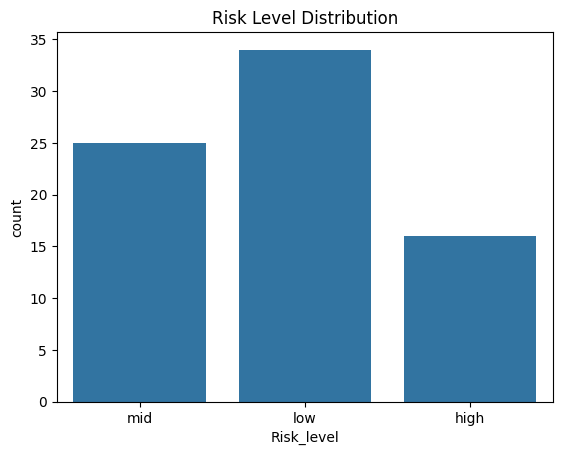

In [312]:
sns.countplot(x='Risk_level', data=train_df)
plt.title("Risk Level Distribution")
plt.show()

The class distribution shows that low-risk cases are the most frequent, followed by mid-risk and high-risk cases. Although the imbalance is not extreme, high-risk cases are less represented, which may affect the model’s ability to accurately detect more severe conditions.

### **2.2 Missing Values**

In [313]:
train_df.isnull().sum()

,0
gravida,0
parity,0
gestational age (weeks),0
Age (yrs),0
BMI [kg/m²],0
diabetes,0
History of hypertension (y/n),0
Systolic BP,0
Diastolic BP,0
HB,0


The dataset contains no missing values after preprocessing. This ensures data consistency and allows the model to be trained without requiring additional imputation techniques.

### **2.3 Outliers Detection**

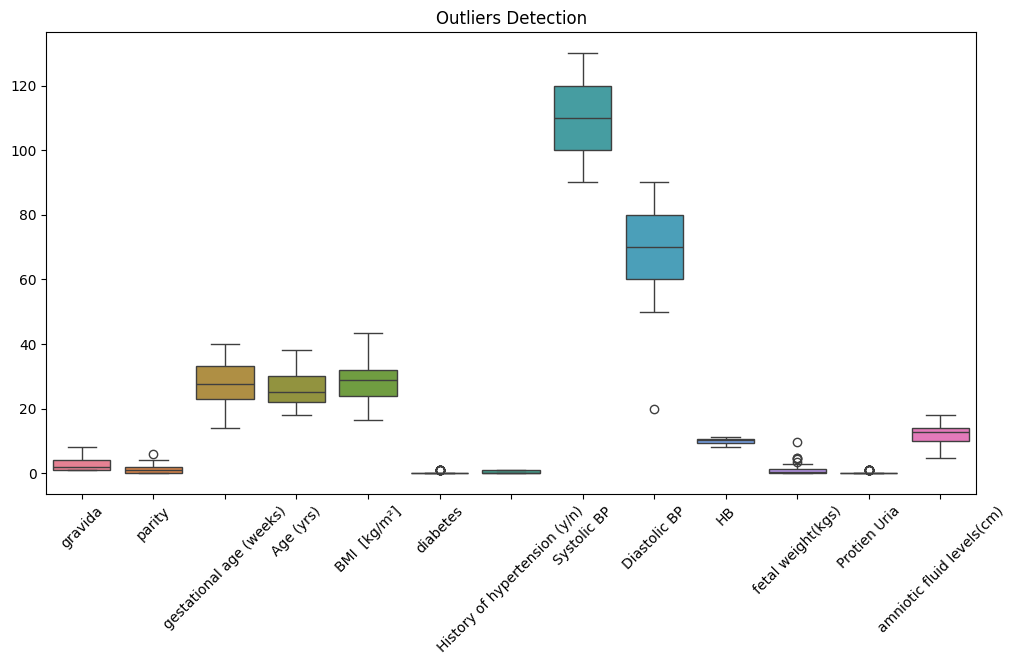

In [314]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train_df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Outliers Detection")
plt.show()

The boxplot reveals the presence of outliers in several numerical features such as blood pressure, BMI, and fetal weight.They may reflect real clinical variation and should be treated carefully.

### **2.4 Handle Outliers**

In [315]:
# Cap outliers using the IQR method
def cap_outliers(df, cols):
    df_capped = df.copy()

    for col in cols:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_capped[col] = np.clip(df_capped[col], lower, upper)

    return df_capped

# Select only numerical columns except target if encoded later
numeric_cols = train_df.select_dtypes(include=np.number).columns
train_df = cap_outliers(train_df, numeric_cols)

Outliers were handled using IQR-based capping, where extreme values were limited within an acceptable range instead of being removed. This approach reduces the influence of extreme observations while preserving the clinical meaning of the data.

### **2.5 Feature Distribution**

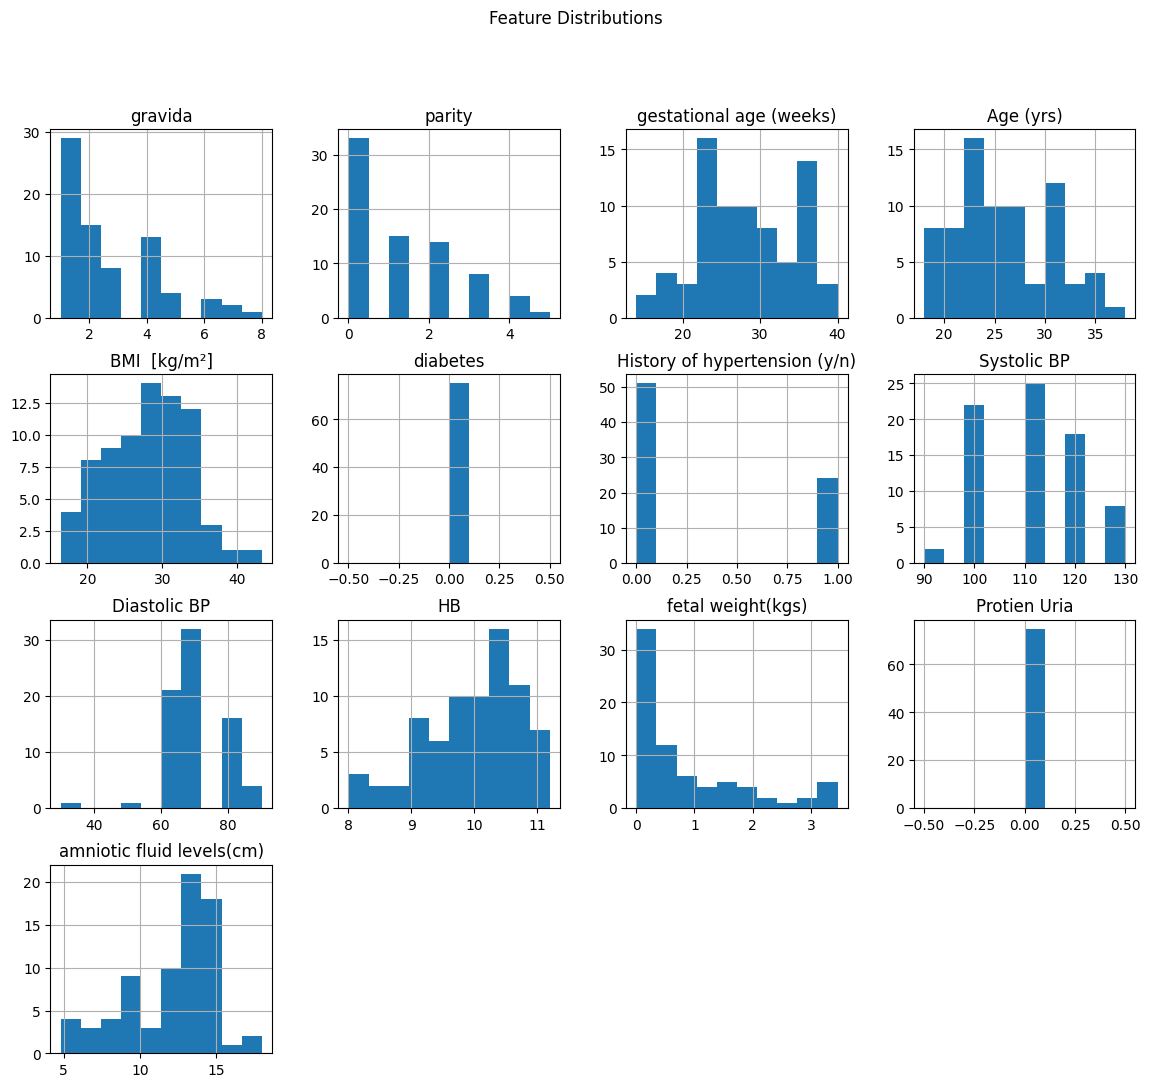

In [316]:
train_df.hist(figsize=(14,12))
plt.suptitle("Feature Distributions")
plt.show()

The histograms show that the dataset contains a mix of continuous and discrete variables. Features such as gestational age, age, BMI, and blood pressure follow reasonable medical ranges, while binary variables such as diabetes and history of hypertension appear as categorical-like distributions.

### **2.6 Correlation Heatmap**

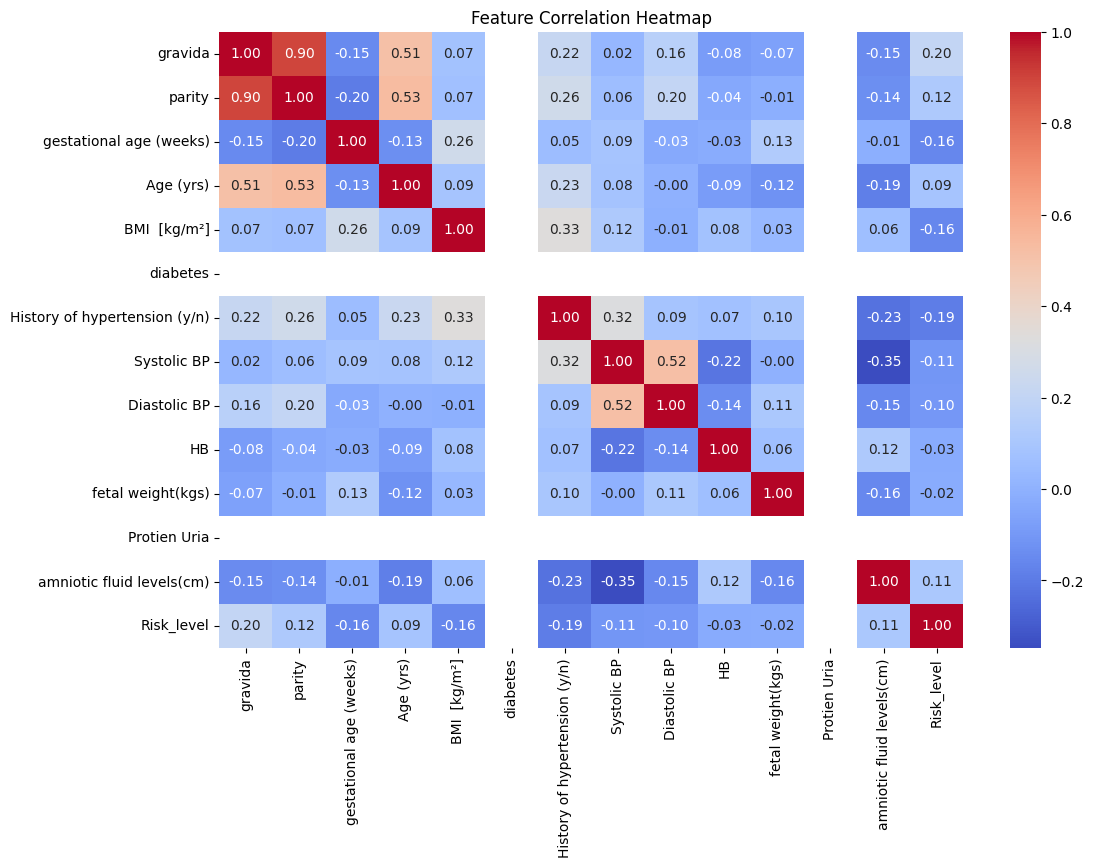

In [317]:
corr_df = train_df.copy()

# ensure target is numeric (only ONCE encoded)
corr_df["Risk_level"] = le.fit_transform(corr_df["Risk_level"])

plt.figure(figsize=(12,8))
sns.heatmap(corr_df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Several features display weak or near-zero correlations, which appear as light or white regions in the heatmap. This is expected due to the presence of binary variables and the relatively small dataset size. Additionally, medical data often exhibits complex and non-linear relationships that are not fully captured by linear correlation measures. Therefore, these results do not indicate poor data quality but rather highlight the need for machine learning models to uncover deeper patterns.

### **Part 3: Preprocessing Pipeline**

### **3.1 Encoding**

In [318]:
train_df["Risk_level"].unique()

array(['mid', 'low', 'high'], dtype=object)

In [319]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df["Risk_level"] = le.fit_transform(train_df["Risk_level"])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'high': np.int64(0), 'low': np.int64(1), 'mid': np.int64(2)}


### **3.2 Define Features and Target**

In [320]:
# Separate predictors and target variable
X = train_df.drop("Risk_level", axis=1)
y = train_df["Risk_level"]

### **3.3 Train / Validation / Test Spli**

In [321]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Check split sizes
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (52, 13)
Validation: (11, 13)
Test: (12, 13)


### **3.4 Feature Scaling**

In [322]:
from sklearn.preprocessing import StandardScaler

# Scale features after splitting to avoid data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### **Part 4: Inject Adversarial Condition**

### **4.1 Handle Imbalance using SMOTE**

In [323]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Check new class distribution
print(pd.Series(y_train_balanced).value_counts())

Risk_level
0    24
2    24
1    24
Name: count, dtype: int64


### **4.2 Inject Label Noise**

In [324]:
# Function to inject random label noise
def inject_label_noise(y, noise_level=0.1):
    y_noisy = y.copy()
    n_samples = int(len(y) * noise_level)

    indices = np.random.choice(len(y), n_samples, replace=False)
    unique_classes = np.unique(y)

    for i in indices:
        current = y_noisy[i]
        choices = list(unique_classes)
        choices.remove(current)
        y_noisy[i] = np.random.choice(choices)

    return y_noisy

# Add 10% label noise to balanced training labels
y_train_noisy = inject_label_noise(y_train_balanced, 0.1)

# Preview class counts after noise
print(pd.Series(y_train_noisy).value_counts())

Risk_level
1    25
2    24
0    23
Name: count, dtype: int64


### **4.3 Final Note on Adversarial Processing**

In [325]:
print("Original training shape:", X_train.shape)
print("Balanced training shape:", X_train_balanced.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Original training shape: (52, 13)
Balanced training shape: (72, 13)
Validation shape: (11, 13)
Test shape: (12, 13)


### **Part 5: Final Dataset Summary**

In [326]:
print("Training set (balanced + noisy):")
print(X_train_balanced.shape, len(y_train_noisy))

print("\nValidation set:")
print(X_val_scaled.shape, len(y_val))

print("\nTest set:")
print(X_test_scaled.shape, len(y_test))

Training set (balanced + noisy):
(72, 13) 72

Validation set:
(11, 13) 11

Test set:
(12, 13) 12


At this stage, the dataset has been fully preprocessed and prepared for machine learning. The training set has been enhanced using SMOTE and label noise to simulate real-world challenges, while the validation and test sets remain clean to ensure reliable evaluation.

### **5.1 Transition to Modeling**

In [327]:
# Final variables to be used in modeling

X_train_final = X_train_balanced
y_train_final = y_train_noisy

X_val_final = X_val_scaled
y_val_final = y_val

X_test_final = X_test_scaled
y_test_final = y_test

---
## **Final Conclusion**

This phase focused on preparing the datasets for machine learning through comprehensive exploratory data analysis and preprocessing techniques.

The EDA process provided insights into data distribution, class imbalance, feature relationships, and the presence of outliers. Visualizations such as histograms, boxplots, and heatmaps helped in understanding the structure and quality of the data.

The preprocessing pipeline ensured data readiness by handling missing values, removing duplicates, encoding categorical variables, scaling features, and splitting the data into training, validation, and test sets.

To enhance the robustness of the models, adversarial conditions were introduced, including class balancing using SMOTE, label noise injection, and feature perturbation (concept drift). These steps simulate real-world challenges such as noisy labels and data variability.

Overall, the datasets are now clean, balanced, and well-structured, making them suitable for reliable and robust model training.

The next phase will focus on training multiple baseline machine learning models, evaluating their performance, and selecting the best-performing models for further optimization.